***Import library***


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

***Load Dataset***


In [2]:
df = pd.read_csv('ispu_dki_all.csv')
df.head()

,tanggal,stasiun,pm25,pm10,so2,co2,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5538 entries, 0 to 5537
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tanggal   5538 non-null   str    
 1   stasiun   5537 non-null   str    
 2   pm25      1516 non-null   float64
 3   pm10      5223 non-null   float64
 4   so2       5408 non-null   float64
 5   co2       5450 non-null   float64
 6   o3        5434 non-null   float64
 7   no2       5432 non-null   float64
 8   max       5537 non-null   float64
 9   critical  5534 non-null   str    
 10  categori  5538 non-null   str    
dtypes: float64(7), str(4)
memory usage: 689.2 KB


***Eksplorasi Data Analisis (EDA)***

In [4]:
df.describe()

,pm25,pm10,so2,co2,o3,no2,max
count,1516.000000,5223.000000,5408.000000,5450.000000,5434.000000,5432.000000,5537.000000
mean,89.742084,56.407046,22.436206,20.422752,77.465771,14.349227,97.625790
std,26.615960,20.010963,15.450584,11.966246,51.798101,10.051099,40.955382
min,10.000000,2.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,71.000000,45.000000,10.000000,12.000000,36.000000,8.000000,70.000000
50%,90.000000,57.000000,18.000000,18.000000,69.000000,12.000000,90.000000
75%,107.000000,67.000000,32.000000,26.000000,103.000000,18.000000,114.000000
max,287.000000,187.000000,112.000000,119.000000,314.000000,202.000000,314.000000


In [5]:
df.categori.value_counts()

categori
SEDANG                3187
TIDAK SEHAT           1827
BAIK                   316
SANGAT TIDAK SEHAT     203
TIDAK ADA DATA           4
BERBAHAYA                1
Name: count, dtype: int64

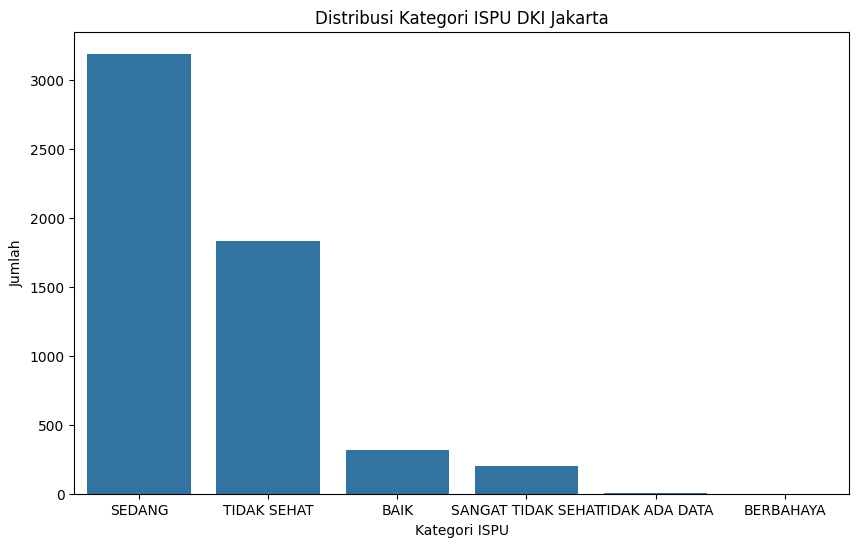

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(x='categori', data=df, order=df['categori'].value_counts().index)

plt.title('Distribusi Kategori ISPU DKI Jakarta')
plt.xlabel('Kategori ISPU')
plt.ylabel('Jumlah')
plt.show()


***Cleaning Data***

In [7]:
print("Missing Value: ")
print(df.isnull().sum())
print("jumlah data duplikat: ", df.duplicated().sum())

Missing Value: 
tanggal        0
stasiun        1
pm25        4022
pm10         315
so2          130
co2           88
o3           104
no2          106
max            1
critical       4
categori       0
dtype: int64
jumlah data duplikat:  0


***Pre Processing***

In [8]:
# Filter kategori valid
valid_labels = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT']
df_clean = df[df['categori'].isin(valid_labels)].copy()
print(f"Baris sebelum filter: {len(df)} → Setelah filter: {len(df_clean)}")

Baris sebelum filter: 5538 → Setelah filter: 5533


In [9]:
# Hapus kolom tidak relevan
cols_to_drop = ['tanggal', 'stasiun', 'critical', 'max']
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

In [10]:
# Hapus missing values dan duplicates
fitur_polutan = ['pm25', 'pm10', 'so2', 'co', 'o3', 'no2']
for col in fitur_polutan:
    if col in df_clean.columns:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

df_clean = df_clean.drop_duplicates().copy()
print(f"Data setelah cleaning: {df_clean.shape}")

Data setelah cleaning: (5532, 7)


In [11]:
# Encoding label target
le = LabelEncoder()
df_clean['label'] = le.fit_transform(df_clean['categori'])
print(f"\nMapping Label:")
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} → {idx}")


Mapping Label:
  BAIK → 0
  SANGAT TIDAK SEHAT → 1
  SEDANG → 2
  TIDAK SEHAT → 3


In [12]:
# Pisahkan fitur dan target
fitur_polutan = ['pm25', 'pm10', 'so2', 'co', 'o3', 'no2']
fitur_ada = [f for f in fitur_polutan if f in df_clean.columns]

X = df_clean[fitur_ada].values
y = df_clean['label'].values

print(f"\nShape X (Fitur): {X.shape}")
print(f"Shape y (Target): {y.shape}")


Shape X (Fitur): (5532, 5)
Shape y (Target): (5532,)


In [13]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nData Latih: {X_train.shape[0]} sampel")
print(f"Data Uji: {X_test.shape[0]} sampel")


Data Latih: 4425 sampel
Data Uji: 1107 sampel


In [14]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Pre-Processing Selesai!")
print(f"Mean setelah scaling: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Std setelah scaling: {X_train_scaled.std(axis=0).round(4)}")

Pre-Processing Selesai!
Mean setelah scaling: [-0.  0. -0. -0.  0.]
Std setelah scaling: [1. 1. 1. 1. 1.]


***EDA Lanjutan***

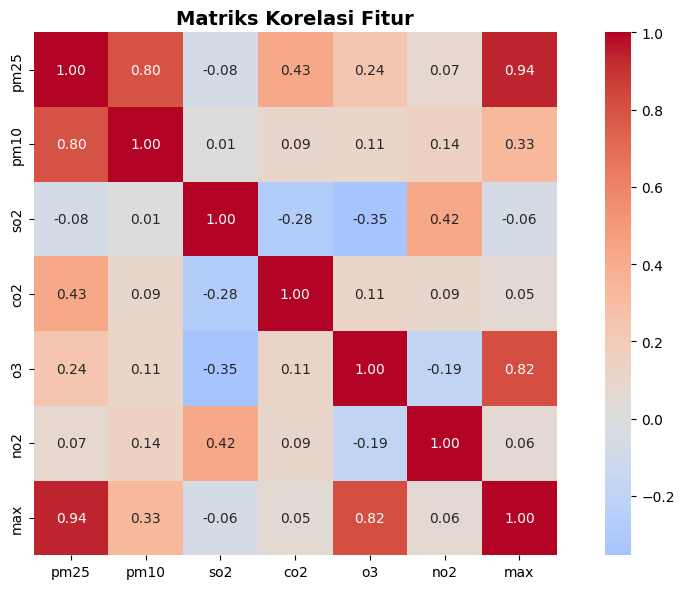

In [15]:
# Heatmap korelasi antar fitur polutan
fig, ax = plt.subplots(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, ax=ax)
plt.title('Matriks Korelasi Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

***Latih Model***

In [16]:
#KNN
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print("KNN Akurasi: ", accuracy_score(y_test, y_pred_knn))

KNN Akurasi:  0.931345980126468


In [17]:
#SVM
svm = SVC(kernel='rbf', C=100, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print("SVM Akurasi: ", accuracy_score(y_test, y_pred_svm))

SVM Akurasi:  0.971093044263776


In [18]:
#Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("Random Forest Akurasi: ", accuracy_score(y_test, y_pred_rf))


Random Forest Akurasi:  0.9846431797651309


***Evaluasi Model***

In [19]:
def hitung_metrik(y_true, y_pred, nama_model):
    return {
        'Model': nama_model,
        'Akurasi': accuracy_score(y_true, y_pred),
        'Presisi': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

hasil = [
    hitung_metrik(y_test, y_pred_knn, 'KNN'),
    hitung_metrik(y_test, y_pred_svm, 'SVM'),
    hitung_metrik(y_test, y_pred_rf, 'Random Forest')
]

df_hasil = pd.DataFrame(hasil).set_index('Model')
print(df_hasil.to_string())

best_model = df_hasil["F1-Score"].idxmax()
print(f"\nModel terbaik berdasarkan F1-Score: {best_model}")

                Akurasi   Presisi    Recall  F1-Score
Model                                                
KNN            0.931346  0.934262  0.931346  0.930950
SVM            0.971093  0.970425  0.971093  0.970389
Random Forest  0.984643  0.984466  0.984643  0.984518

Model terbaik berdasarkan F1-Score: Random Forest
